# Training and Inference — UNeXt on the BUSI dataset

This notebook:
1. Loads the train/val/test IDs generated in the preprocessing notebook
2. Trains the UNeXt model with BCEDiceLoss
3. Saves the best model (best validation IoU)
4. Runs inference on the validation and test sets
5. Saves the **probabilities** (after sigmoid) in `.npz` files in the `data/` folder with key `p_hat`

> **Prerequisite:** run `01_preprocessing_BUSI.ipynb` before this notebook.

In [1]:
import os
import sys
import math
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.optim import lr_scheduler
from collections import OrderedDict
from typing import List

import pandas as pd
from tqdm import tqdm

import albumentations as A
from albumentations.augmentations import transforms as AT
from albumentations.core.composition import Compose
from albumentations import RandomRotate90, Resize

# Add the UNeXt directory to path to import archs, losses, metrics
BASE_DIR  = "./"
UNEXT_DIR = os.path.join(BASE_DIR, "UNeXt-pytorch-main")
MEDICAL_DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', '..', 'medical-imaging', 'data'))
os.makedirs(MEDICAL_DATA_DIR, exist_ok=True)
if UNEXT_DIR not in sys.path:
    sys.path.insert(0, UNEXT_DIR)

from losses  import BCEDiceLoss
from metrics import iou_score
from utils   import AverageMeter

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA avail.: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/home/bruno-borges/miniconda3/envs/unext/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 1.9.1+cu111
CUDA avail.: True
GPU       : NVIDIA GeForce RTX 3090
Device: cuda


## UNeXt model definition

The model is defined directly here to avoid dependency on `mmcv` (imported in `archs.py` but not used in UNeXt classes).

In [2]:
from timm.models.layers import DropPath, to_2tuple, trunc_normal_


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        return x.flatten(2).transpose(1, 2)


class shiftmlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0., shift_size=5):
        super().__init__()
        out_features    = out_features    or in_features
        hidden_features = hidden_features or in_features
        self.dim        = in_features
        self.fc1        = nn.Linear(in_features, hidden_features)
        self.dwconv     = DWConv(hidden_features)
        self.act        = act_layer()
        self.fc2        = nn.Linear(hidden_features, out_features)
        self.drop       = nn.Dropout(drop)
        self.shift_size = shift_size
        self.pad        = shift_size // 2
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        # Shift rows
        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad,)*4, "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(xc, s, 2) for xc, s in zip(xs, range(-self.pad, self.pad+1))]
        x_cat   = torch.cat(x_shift, 1)
        x_cat   = torch.narrow(x_cat, 2, self.pad, H)
        x_s     = torch.narrow(x_cat, 3, self.pad, W)
        x_s     = x_s.reshape(B, C, H*W).contiguous().transpose(1, 2)
        x       = self.fc1(x_s)
        x       = self.dwconv(x, H, W)
        x       = self.act(x)
        x       = self.drop(x)
        # Shift cols
        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad,)*4, "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(xc, s, 3) for xc, s in zip(xs, range(-self.pad, self.pad+1))]
        x_cat   = torch.cat(x_shift, 1)
        x_cat   = torch.narrow(x_cat, 2, self.pad, H)
        x_s     = torch.narrow(x_cat, 3, self.pad, W)
        x_s     = x_s.reshape(B, C, H*W).contiguous().transpose(1, 2)
        x       = self.fc2(x_s)
        return self.drop(x)


class shiftedBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None,
                 drop=0., attn_drop=0., drop_path=0., act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2     = norm_layer(dim)
        self.mlp       = shiftmlp(in_features=dim,
                                  hidden_features=int(dim * mlp_ratio),
                                  act_layer=act_layer, drop=drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        return x + self.drop_path(self.mlp(self.norm2(x), H, W))


class OverlapPatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size   = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.proj  = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size,
                               stride=stride,
                               padding=(patch_size[0]//2, patch_size[1]//2))
        self.norm  = nn.LayerNorm(embed_dim)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), H, W


class UNext(nn.Module):
    """UNeXt: Conv 3 + shifted MLP 2."""

    def __init__(self, num_classes, input_channels=3, deep_supervision=False,
                 img_size=256, embed_dims=[128, 160, 256],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4],
                 qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0.,
                 norm_layer=nn.LayerNorm, depths=[1, 1, 1],
                 sr_ratios=[8, 4, 2, 1], **kwargs):
        super().__init__()

        self.encoder1 = nn.Conv2d(3,   16,  3, stride=1, padding=1)
        self.encoder2 = nn.Conv2d(16,  32,  3, stride=1, padding=1)
        self.encoder3 = nn.Conv2d(32, 128,  3, stride=1, padding=1)
        self.ebn1 = nn.BatchNorm2d(16)
        self.ebn2 = nn.BatchNorm2d(32)
        self.ebn3 = nn.BatchNorm2d(128)

        self.norm3  = norm_layer(embed_dims[1])
        self.norm4  = norm_layer(embed_dims[2])
        self.dnorm3 = norm_layer(160)
        self.dnorm4 = norm_layer(128)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        self.block1  = nn.ModuleList([shiftedBlock(embed_dims[1], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[0], norm_layer=norm_layer)])
        self.block2  = nn.ModuleList([shiftedBlock(embed_dims[2], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[1], norm_layer=norm_layer)])
        self.dblock1 = nn.ModuleList([shiftedBlock(embed_dims[1], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[0], norm_layer=norm_layer)])
        self.dblock2 = nn.ModuleList([shiftedBlock(embed_dims[0], num_heads[0], mlp_ratio=1,
                                                   drop=drop_rate, attn_drop=attn_drop_rate,
                                                   drop_path=dpr[1], norm_layer=norm_layer)])

        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size//4,  patch_size=3,
                                              stride=2, in_chans=embed_dims[0],
                                              embed_dim=embed_dims[1])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size//8,  patch_size=3,
                                              stride=2, in_chans=embed_dims[1],
                                              embed_dim=embed_dims[2])

        self.decoder1 = nn.Conv2d(256, 160, 3, stride=1, padding=1)
        self.decoder2 = nn.Conv2d(160, 128, 3, stride=1, padding=1)
        self.decoder3 = nn.Conv2d(128,  32, 3, stride=1, padding=1)
        self.decoder4 = nn.Conv2d(32,   16, 3, stride=1, padding=1)
        self.decoder5 = nn.Conv2d(16,   16, 3, stride=1, padding=1)
        self.dbn1 = nn.BatchNorm2d(160)
        self.dbn2 = nn.BatchNorm2d(128)
        self.dbn3 = nn.BatchNorm2d(32)
        self.dbn4 = nn.BatchNorm2d(16)

        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        B = x.shape[0]
        out = F.relu(F.max_pool2d(self.ebn1(self.encoder1(x)), 2, 2)); t1 = out
        out = F.relu(F.max_pool2d(self.ebn2(self.encoder2(out)), 2, 2)); t2 = out
        out = F.relu(F.max_pool2d(self.ebn3(self.encoder3(out)), 2, 2)); t3 = out

        out, H, W = self.patch_embed3(out)
        for blk in self.block1:
            out = blk(out, H, W)
        out = self.norm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous(); t4 = out

        out, H, W = self.patch_embed4(out)
        for blk in self.block2:
            out = blk(out, H, W)
        out = self.norm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

        out = F.relu(F.interpolate(self.dbn1(self.decoder1(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t4)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock1:
            out = blk(out, H, W)

        out = self.dnorm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        out = F.relu(F.interpolate(self.dbn2(self.decoder2(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t3)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock2:
            out = blk(out, H, W)

        out = self.dnorm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        out = F.relu(F.interpolate(self.dbn3(self.decoder3(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t2)
        out = F.relu(F.interpolate(self.dbn4(self.decoder4(out)), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t1)
        out = F.relu(F.interpolate(self.decoder5(out), scale_factor=2, mode='bilinear', align_corners=False))
        return self.final(out)


print('UNeXt model defined.')

UNeXt model defined.


In [3]:
# ─── Configuration ─────────────────────────────────────────────────────────────
config = {
    # Dados
    'dataset'       : 'BUSI',
    'img_ext'       : '.png',
    'mask_ext'      : '.png',
    'num_classes'   : 1,
    'input_channels': 3,

    # Model input resolution (must be divisible by 32)
    'input_h': 256,
    'input_w': 256,

    # Training
    'epochs'         : 400,
    'batch_size'     : 8,
    'num_workers'    : 4,
    'lr'             : 1e-4,
    'weight_decay'   : 1e-4,
    'deep_supervision': False,
    'early_stopping' : 20,   # stop if IoU does not improve for N epochs

    # Paths
    'inputs_dir' : os.path.join(UNEXT_DIR, 'inputs', 'BUSI'),
    'models_dir' : os.path.join(BASE_DIR,  'models', 'UNeXt_BUSI'),
    'data_dir'   : os.path.join(BASE_DIR,  'data'),
}

os.makedirs(config['models_dir'], exist_ok=True)
os.makedirs(config['data_dir'],   exist_ok=True)

for k, v in config.items():
    print(f'  {k:20s}: {v}')

  dataset             : BUSI
  img_ext             : .png
  mask_ext            : .png
  num_classes         : 1
  input_channels      : 3
  input_h             : 256
  input_w             : 256
  epochs              : 400
  batch_size          : 8
  num_workers         : 4
  lr                  : 0.0001
  weight_decay        : 0.0001
  deep_supervision    : False
  early_stopping      : 20
  inputs_dir          : ./UNeXt-pytorch-main/inputs/BUSI
  models_dir          : ./models/UNeXt_BUSI
  data_dir            : ./data


In [4]:
# ─── Load split IDs ───────────────────────────────────────────────────
def load_ids(split: str) -> List[str]:
    path = os.path.join(config['inputs_dir'], f'{split}_ids.txt')
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

train_ids = load_ids('train')
val_ids   = load_ids('val')
test_ids  = load_ids('test')

print(f'Train     : {len(train_ids)}')
print(f'Validation: {len(val_ids)}')
print(f'Test      : {len(test_ids)}')

Train     : 450
Validation: 99
Test      : 98


In [5]:
# ─── Dataset ──────────────────────────────────────────────────────────────────
class BUSIDataset(torch.utils.data.Dataset):
    """Dataset BUSI no formato UNeXt (images/ e masks/0/)."""

    def __init__(self, img_ids, img_dir, mask_dir, img_ext, mask_ext,
                 num_classes, transform=None):
        self.img_ids     = img_ids
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.img_ext     = img_ext
        self.mask_ext    = mask_ext
        self.num_classes = num_classes
        self.transform   = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img = cv2.imread(os.path.join(self.img_dir, img_id + self.img_ext))

        # Load one mask per class (here: class 0 = lesion)
        mask = []
        for c in range(self.num_classes):
            m = cv2.imread(
                os.path.join(self.mask_dir, str(c), img_id + self.mask_ext),
                cv2.IMREAD_GRAYSCALE
            )
            mask.append(m[..., None])
        mask = np.dstack(mask)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        img  = img.astype('float32') / 255.0
        img  = img.transpose(2, 0, 1)         # (C, H, W)
        mask = mask.astype('float32') / 255.0
        mask = mask.transpose(2, 0, 1)        # (1, H, W)

        return img, mask, {'img_id': img_id}


# Transforms
train_transform = Compose([
    RandomRotate90(),
    AT.Flip(),
    Resize(config['input_h'], config['input_w']),
    AT.Normalize(),
])

val_transform = Compose([
    Resize(config['input_h'], config['input_w']),
    AT.Normalize(),
])

img_dir  = os.path.join(config['inputs_dir'], 'images')
mask_dir = os.path.join(config['inputs_dir'], 'masks')

train_ds = BUSIDataset(train_ids, img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], train_transform)
val_ds   = BUSIDataset(val_ids,   img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], val_transform)
test_ds  = BUSIDataset(test_ids,  img_dir, mask_dir,
                       config['img_ext'], config['mask_ext'],
                       config['num_classes'], val_transform)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=config['batch_size'], shuffle=True,
    num_workers=config['num_workers'], drop_last=True, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(
    val_ds,   batch_size=config['batch_size'], shuffle=False,
    num_workers=config['num_workers'], pin_memory=True)
test_loader  = torch.utils.data.DataLoader(
    test_ds,  batch_size=1, shuffle=False,
    num_workers=config['num_workers'], pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 56
Val   batches: 13
Test  batches: 98


In [6]:
# ─── Model, criterion, optimizer and scheduler ─────────────────────────────────
model     = UNext(num_classes=config['num_classes'],
                  input_channels=config['input_channels'],
                  img_size=config['input_h']).to(DEVICE)
criterion = BCEDiceLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(),
                       lr=config['lr'],
                       weight_decay=config['weight_decay'],
                       betas=(0.9, 0.999))
scheduler = lr_scheduler.CosineAnnealingLR(optimizer,
                                           T_max=config['epochs'],
                                           eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 1,471,921


In [7]:
# ─── Training and validation functions ───────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    meters = {'loss': AverageMeter(), 'iou': AverageMeter()}
    pbar   = tqdm(loader, desc='  Train', leave=False)
    for imgs, masks, _ in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        out  = model(imgs)
        loss = criterion(out, masks)
        iou, _ = iou_score(out, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        meters['loss'].update(loss.item(), imgs.size(0))
        meters['iou'].update(iou, imgs.size(0))
        pbar.set_postfix(loss=f'{meters["loss"].avg:.4f}', iou=f'{meters["iou"].avg:.4f}')
    return {k: v.avg for k, v in meters.items()}


def val_epoch(model, loader, criterion, device):
    model.eval()
    meters = {'loss': AverageMeter(), 'iou': AverageMeter(), 'dice': AverageMeter()}
    pbar   = tqdm(loader, desc='  Val  ', leave=False)
    with torch.no_grad():
        for imgs, masks, _ in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            out  = model(imgs)
            loss = criterion(out, masks)
            iou, dice = iou_score(out, masks)
            meters['loss'].update(loss.item(), imgs.size(0))
            meters['iou'].update(iou, imgs.size(0))
            meters['dice'].update(dice, imgs.size(0))
            pbar.set_postfix(iou=f'{meters["iou"].avg:.4f}', dice=f'{meters["dice"].avg:.4f}')
    return {k: v.avg for k, v in meters.items()}


print('Training functions defined.')

Training functions defined.


In [8]:
# ─── Training loop ──────────────────────────────────────────────────────
best_iou  = 0.0
no_improve = 0
log_rows  = []
model_path = os.path.join(config['models_dir'], 'best_model.pth')

for epoch in range(1, config['epochs'] + 1):
    train_log = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_log   = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:3d}/{config['epochs']}  "
          f"loss={train_log['loss']:.4f}  iou={train_log['iou']:.4f}  "
          f"val_loss={val_log['loss']:.4f}  val_iou={val_log['iou']:.4f}  "
          f"val_dice={val_log['dice']:.4f}  lr={lr_now:.2e}")

    log_rows.append({'epoch': epoch, 'lr': lr_now,
                     **{f'train_{k}': v for k, v in train_log.items()},
                     **{f'val_{k}':   v for k, v in val_log.items()}})

    if val_log['iou'] > best_iou:
        best_iou   = val_log['iou']
        no_improve = 0
        torch.save(model.state_dict(), model_path)
        print(f'  => Best model saved  (val_iou={best_iou:.4f})')
    else:
        no_improve += 1

    if config['early_stopping'] > 0 and no_improve >= config['early_stopping']:
        print(f'Early stopping triggered at epoch {epoch}.')
        break

    torch.cuda.empty_cache()

# Save log to CSV
log_df = pd.DataFrame(log_rows)
log_df.to_csv(os.path.join(config['models_dir'], 'training_log.csv'), index=False)
print(f'\nTraining complete. Best val_iou = {best_iou:.4f}')
print(f'Model saved at: {model_path}')

  Train:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch   1/400  loss=1.0745  iou=0.0610  val_loss=1.1193  val_iou=0.0224  val_dice=0.0424  lr=1.00e-04
  => Best model saved  (val_iou=0.0224)


Epoch   2/400  loss=0.9694  iou=0.3354  val_loss=0.9899  val_iou=0.1416  val_dice=0.2325  lr=1.00e-04
  => Best model saved  (val_iou=0.1416)


Epoch   3/400  loss=0.8673  iou=0.3875  val_loss=0.8446  val_iou=0.3604  val_dice=0.5179  lr=1.00e-04
  => Best model saved  (val_iou=0.3604)


Epoch   4/400  loss=0.7833  iou=0.4033  val_loss=0.7582  val_iou=0.3755  val_dice=0.5402  lr=1.00e-04
  => Best model saved  (val_iou=0.3755)


...

Epoch 104/400  loss=0.2138  iou=0.7505  val_loss=0.3980  val_iou=0.5827  val_dice=0.7290  lr=8.58e-05


Epoch 105/400  loss=0.2199  iou=0.7520  val_loss=0.4151  val_iou=0.5267  val_dice=0.6796  lr=8.55e-05


Epoch 106/400  loss=0.2235  iou=0.7386  val_loss=0.4089  val_iou=0.5463  val_dice=0.6991  lr=8.53e-05


Epoch 107/400  loss=0.2130  iou=0.7576  val_loss=0.3861  val_iou=0.5552  val_dice=0.7032  lr=8.50e-05


Epoch 108/400  loss=0.2113  iou=0.7516  val_loss=0.4165  val_iou=0.5264  val_dice=0.6776  lr=8.48e-05
Early stopping triggered at epoch 108.

Training complete. Best val_iou = 0.6055
Model saved at: ./models/UNeXt_BUSI/best_model.pth


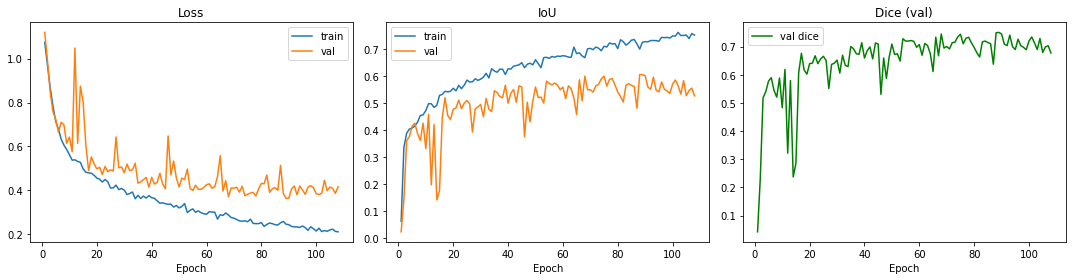

In [9]:
# ─── Learning curves ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

log_df = pd.read_csv(os.path.join(config['models_dir'], 'training_log.csv'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(log_df['epoch'], log_df['train_iou'], label='train')
axes[1].plot(log_df['epoch'], log_df['val_iou'],   label='val')
axes[1].set_title('IoU'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(log_df['epoch'], log_df['val_dice'], label='val dice', color='green')
axes[2].set_title('Dice (val)'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(config['models_dir'], 'learning_curves.png'), dpi=120)
plt.show()

In [10]:
# ─── Inference — generic function ─────────────────────────────────────────────
def run_inference(model, loader, device, out_dir, split_name):
    """Saves per-image .npz files and returns stacked (p_hat, y) arrays.

    Each per-image file contains:
      - 'p_hat'  : np.float32, shape (1, H, W), values in [0, 1]
      - 'img_id' : str
    """
    model.eval()
    os.makedirs(out_dir, exist_ok=True)
    ious, dices = [], []
    p_hat_list, y_list = [], []

    with torch.no_grad():
        for imgs, masks, meta in tqdm(loader, desc=f'Inference {split_name}'):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)          # (B, 1, H, W) — raw logits

            iou, dice = iou_score(logits, masks)   # iou_score applies sigmoid internally
            ious.append(iou)
            dices.append(dice)

            p_hat = torch.sigmoid(logits).cpu().numpy()  # (B, 1, H, W) ∈ [0, 1]
            y     = masks.cpu().numpy()                  # (B, 1, H, W) ∈ {0, 1}
            p_hat_list.append(p_hat)
            y_list.append(y)
            for i, img_id in enumerate(meta['img_id']):
                npz_path = os.path.join(out_dir, f'{img_id}.npz')
                np.savez_compressed(npz_path,
                                    p_hat=p_hat[i],
                                    img_id=np.array(img_id))

    mean_iou  = np.mean(ious)
    mean_dice = np.mean(dices)
    print(f'[{split_name}] IoU={mean_iou:.4f}  Dice={mean_dice:.4f}')
    print(f'.npz files saved at: {out_dir}')
    return mean_iou, mean_dice, np.concatenate(p_hat_list, axis=0), np.concatenate(y_list, axis=0)


print('Inference function defined.')

Inference function defined.


In [11]:
# ─── Load best model ──────────────────────────────────────────────────
best_model = UNext(num_classes=config['num_classes'],
                   input_channels=config['input_channels'],
                   img_size=config['input_h']).to(DEVICE)
best_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
best_model.eval()
print(f'Model loaded from: {model_path}')

Model loaded from: ./models/UNeXt_BUSI/best_model.pth


In [12]:
# ─── Inference — Validation ───────────────────────────────────────────────────
val_out_dir = os.path.join(config['data_dir'], 'val')
val_iou, val_dice, _, _ = run_inference(best_model, val_loader, DEVICE, val_out_dir, 'val')

Inference val: 100%|██████████| 13/13 [00:01<00:00, 11.05it/s]

[val] IoU=0.6140  Dice=0.7554
.npz files saved at: ./data/val


In [13]:
# ─── Inference — Test ─────────────────────────────────────────────────────────
test_out_dir = os.path.join(config['data_dir'], 'test')
test_iou, test_dice, p_hat_test, y_test = run_inference(best_model, test_loader, DEVICE, test_out_dir, 'test')

busi_npz = os.path.join(MEDICAL_DATA_DIR, 'busi.npz')
np.savez_compressed(busi_npz, p_hat=p_hat_test, y=y_test)
print(f'Consolidated test data → {busi_npz}')
print(f'  p_hat: {p_hat_test.shape}  y: {y_test.shape}')

Inference test: 100%|██████████| 98/98 [00:01<00:00, 72.67it/s]

[test] IoU=0.6301  Dice=0.7160
.npz files saved at: ./data/test


In [14]:
# ─── Final summary ─────────────────────────────────────────────────────────────
print('=' * 50)
print('FINAL RESULTS')
print('=' * 50)
print(f'Validation →  IoU={val_iou:.4f}   Dice={val_dice:.4f}')
print(f'Test       →  IoU={test_iou:.4f}   Dice={test_dice:.4f}')
print()
print('Output:')
print(f'  Model    : {model_path}')
print(f'  busi.npz : {busi_npz}  (p_hat={p_hat_test.shape})')

FINAL RESULTS
Validation →  IoU=0.6140   Dice=0.7554
Test       →  IoU=0.6301   Dice=0.7160

Output structure:
  Model       : ./models/UNeXt_BUSI/best_model.pth
  p_hat val   : ./data/val/*.npz
  p_hat test  : ./data/test/*.npz

Para carregar um arquivo de probabilidades:
  data  = np.load('<path>.npz')
  p_hat = data['p_hat']              # shape (1, H, W), values in [0, 1]
  pred  = (p_hat > 0.5).astype(np.uint8)


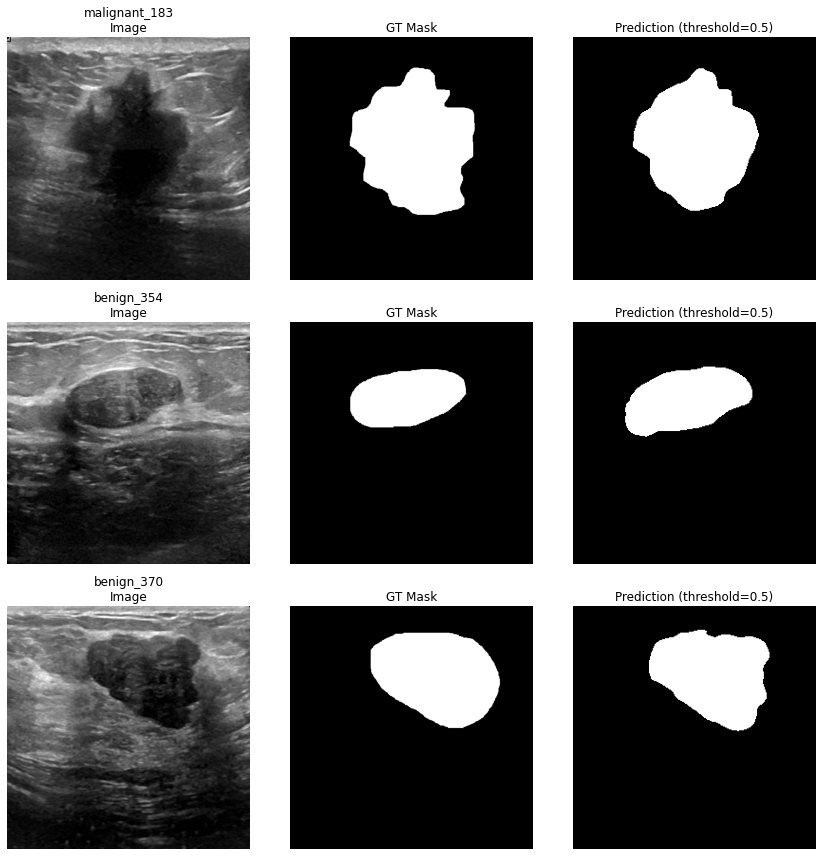

In [15]:
# ─── Visual verification of predictions (3 val samples) ─────────────────────
import matplotlib.pyplot as plt

sample_ids_vis = val_ids[:3]
fig, axes = plt.subplots(len(sample_ids_vis), 3, figsize=(12, 4 * len(sample_ids_vis)))

for i, img_id in enumerate(sample_ids_vis):
    img  = cv2.cvtColor(cv2.imread(os.path.join(img_dir, f'{img_id}.png')), cv2.COLOR_BGR2RGB)
    gt   = cv2.imread(os.path.join(mask_dir, '0', f'{img_id}.png'), cv2.IMREAD_GRAYSCALE)
    npz  = np.load(os.path.join(val_out_dir, f'{img_id}.npz'))
    p_hat = npz['p_hat'][0]                          # (H, W) ∈ [0, 1]
    pred  = (p_hat > 0.5).astype(np.uint8) * 255

    axes[i, 0].imshow(img); axes[i, 0].set_title(f'{img_id}\nImage'); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title('GT Mask'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title('Prediction (threshold=0.5)'); axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config['models_dir'], 'val_predictions_sample.png'), dpi=120)
plt.show()